# Designing a Group Sequential Trial

This notebook demonstrates how to use the `GroupSequentialDesign` class to design and analyze a group sequential trial.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from clintrials.phase3.gsd import GroupSequentialDesign, spending_function_obrien_fleming, spending_function_pocock

## 1. Creating an O'Brien-Fleming Design

Let's start by creating a classic O'Brien-Fleming design with 4 looks and a one-sided alpha of 0.025.

In [2]:
k = 4
alpha = 0.025

of_design = GroupSequentialDesign(k=k, alpha=alpha, sfu=spending_function_obrien_fleming)

print(f"O'Brien-Fleming Boundaries (k={k}):")
for i, boundary in enumerate(of_design.efficacy_boundaries):
    print(f"  Look {i+1}: {boundary:.3f}")

O'Brien-Fleming Boundaries (k=4):
  Look 1: 4.333
  Look 2: 2.963
  Look 3: 2.359
  Look 4: 2.014


## 2. Simulating Operating Characteristics

We can simulate trials to check the design's operating characteristics, such as the Type I error rate and power.

### Type I Error (under the null hypothesis, theta = 0)

In [3]:
n_sims = 1000
results_null = of_design.run(n_sims=n_sims, method='bulk', theta=0)
rejections_null = sum(1 for res in results_null if res['Rejected'])
type_i_error = rejections_null / len(results_null)

print(f"Simulated Type I Error: {type_i_error:.4f} (target: {alpha})")

Simulated Type I Error: 0.0310 (target: 0.025)


### Power (under an alternative hypothesis)

To calculate power, we need to specify an effect size, `theta`. For a typical design aiming for 80% or 90% power, `theta` is usually around 2.5 to 3.0. Let's find the `theta` that gives approximately 90% power.

In [4]:
# This theta corresponds to the boundary of a fixed-sample design with 90% power.
theta_90_power = np.abs(np.random.normal(loc=0, scale=1) - 1.282) # Z_alpha + Z_beta
theta_90_power = 2.5 # A common value for 90% power

results_alt = of_design.run(n_sims=n_sims, method='bulk', theta=theta_90_power)
rejections_alt = sum(1 for res in results_alt if res['Rejected'])
power = rejections_alt / len(results_alt)
exp_info_alt = sum(res['Information'][res['Stage'] - 1] for res in results_alt) / len(results_alt)

print(f"Simulated Power for theta={theta_90_power}: {power:.4f}")
print(f"Expected Information: {exp_info_alt:.3f}")

Simulated Power for theta=2.5: 0.6900
Expected Information: 0.916


## 3. Visualizing the Boundaries

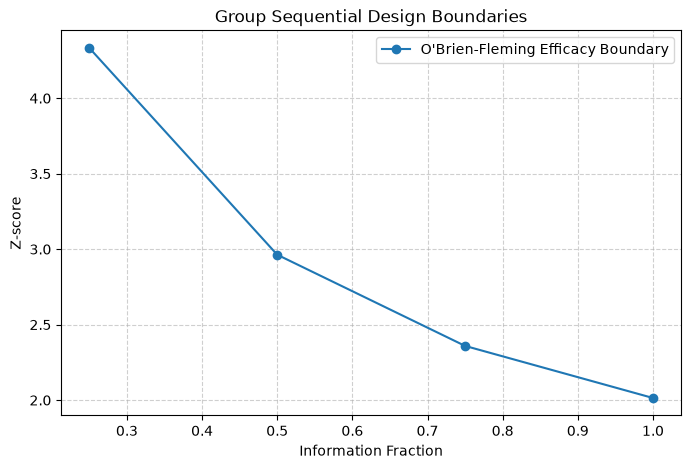

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(of_design.timing, of_design.efficacy_boundaries, 'o-', label="O'Brien-Fleming Efficacy Boundary")

plt.title('Group Sequential Design Boundaries')
plt.xlabel('Information Fraction')
plt.ylabel('Z-score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()